In [2]:
from astropy.io import fits
from matplotlib import pyplot as plt
import numpy as np
# Importing the ReducedArm Class
from qmostcomm.reducedarm import ReducedArm, FibUse

In [216]:
# Reading in a simulated QC1 reduced output file
path = '/Users/sp624AA/Downloads/spv_misc/nt_100051.fit'

# Seeing what extensions are available
with fits.open(path) as hdulist:
    hdulist.info()

Filename: /Users/sp624AA/Downloads/spv_misc/nt_100051.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     684   ()      
  1  RED_DATA      1 ImageHDU       267   (10281, 824)   float32   
  2  RED_IVAR      1 ImageHDU       256   (10281, 824)   float32   
  3  RED_DATA_NOSS    1 ImageHDU       256   (10281, 824)   float32   
  4  RED_IVAR_NOSS    1 ImageHDU       256   (10281, 824)   float32   
  5  RED_SENSFUNC    1 ImageHDU        36   (10281, 824)   float32   
  6  GREEN_DATA    1 ImageHDU       267   (7041, 824)   float32   
  7  GREEN_IVAR    1 ImageHDU       256   (7041, 824)   float32   
  8  GREEN_DATA_NOSS    1 ImageHDU       256   (7041, 824)   float32   
  9  GREEN_IVAR_NOSS    1 ImageHDU       256   (7041, 824)   float32   
 10  GREEN_SENSFUNC    1 ImageHDU        36   (7041, 824)   float32   
 11  BLUE_DATA     1 ImageHDU       267   (6881, 824)   float32   
 12  BLUE_IVAR     1 ImageHDU       256   (6881, 824)   float32  

In [217]:
#print primary header
with fits.open(path) as hdulist:
    print(hdulist[0].header)

SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                    8 / number of bits per data pixel                  NAXIS   =                    0 / number of data axes                            EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H ORIGIN  = 'ESO-PARANAL'        / European Southern Observatory                  DATE    = '2025-11-20T04:03:40.398'     / Date this file was written            TELESCOP= 'VISTA   '           / ESO <TEL>                                      INSTRUME= 'QMOST   '           / Instrument used.                               OBJECT  = '0350    '           / Original target.                               RA      =           359.782929 / [deg] 23:59:07.9 RA (J2000) pointing           DEC     =            -30.62796 / [deg] -

In [218]:
# Let's now initialise a ReducedArm class for the red arm
with fits.open(path) as hdulist:
    primary_header = hdulist[0].header
    counts = hdulist['GREEN_DATA']
    ivar = hdulist['GREEN_IVAR']
    noss_flux = hdulist['GREEN_DATA_NOSS'] 
    noss_ivar = hdulist['GREEN_IVAR_NOSS'] 
    sensfunc = hdulist['GREEN_SENSFUNC']
    fibinfo = hdulist['FIBINFO']
    
    green_arm = ReducedArm(HEADER=primary_header, # This is required
                         ARM_DATA=counts, # This is required
                         ARM_IVAR=ivar, # This is required
                         ARM_DATA_NOSS=noss_flux,  # This is optional
                         ARM_IVAR_NOSS=noss_ivar,  # This is optional
                         ARM_SENSFUNC=sensfunc,  # This is optional
                         fibinfo=fibinfo  # This is optional
                        )

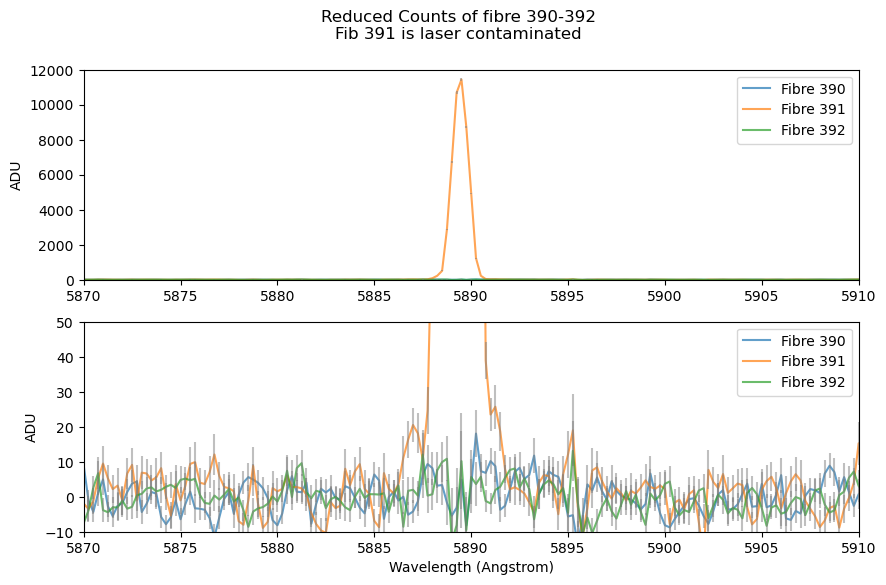

In [219]:
# figure, 2 panels, same x-axis, different y-axis
fig = plt.figure(figsize=(10, 6))
# ivar2D is the inverse variance of the flux2D, so we can calculate the error as 1/sqrt(ivar2D)
ax1 = fig.add_subplot(211)
for i in range(390, 393):
    ax1.plot(green_arm.wavelength, green_arm.counts2D[i], label = f'Fibre {i}', alpha=0.7)
    ax1.errorbar(green_arm.wavelength, green_arm.counts2D[i], yerr=1/np.sqrt(green_arm.ivar2D[i]), fmt='none', ecolor='gray', alpha=0.5)
ax1.set_ylim(0, 12000)
#ax1.set_ylim(-5e-14, 5e-14)
ax1.set_ylabel('ADU')
ax1.legend()

ax2 = fig.add_subplot(212, sharex=ax1)
for i in range(390, 393):
    ax2.plot(green_arm.wavelength, green_arm.counts2D[i], label = f'Fibre {i}', alpha=0.7)
    ax2.errorbar(green_arm.wavelength, green_arm.counts2D[i], yerr=1/np.sqrt(green_arm.ivar2D[i]), fmt='none', ecolor='gray', alpha=0.5)
ax2.set_ylim(-10, 50)
ax2.set_xlim(5870, 5910)
ax2.set_xlabel('Wavelength (Angstrom)')
ax2.set_ylabel('ADU')
ax2.legend()

plt.suptitle(f'Reduced Counts of fibre 390-392\nFib 391 is laser contaminated')
plt.savefig('reduced_counts_fib391.png')
#plt.plot(green_arm.wavelength, green_arm.counts2D[391])
#plt.xlim(5875, 5925)
#plt.ylim(-5e-16, 5e-16)

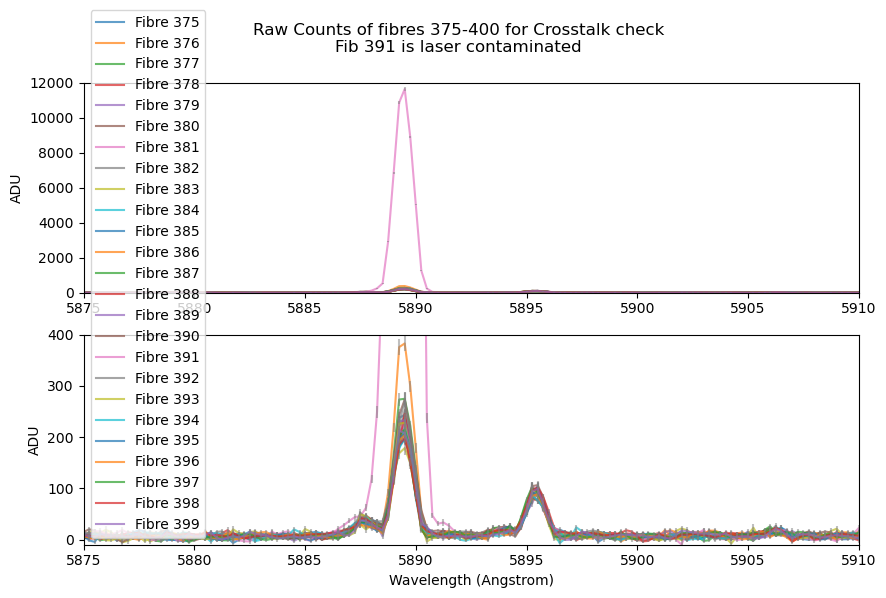

In [220]:
# figure, 2 panels, same x-axis, different y-axis
fig = plt.figure(figsize=(10, 6))
# ivar2D is the inverse variance of the flux2D, so we can calculate the error as 1/sqrt(ivar2D)
fib_no_min = 375
fib_no_max = 400
ax1 = fig.add_subplot(211)
for i in range(fib_no_min, fib_no_max):
    ax1.plot(green_arm.wavelength, green_arm.raw_counts2D[i], label = f'Fibre {i}', alpha=0.7)
    ax1.errorbar(green_arm.wavelength, green_arm.raw_counts2D[i], yerr=1/np.sqrt(green_arm.raw_ivar2D[i]), fmt='none', ecolor='gray', alpha=0.5)
ax1.set_ylim(0, 12000)
#ax1.set_ylim(-5e-14, 5e-14)
ax1.set_ylabel('ADU')
#ax1.legend()

ax2 = fig.add_subplot(212, sharex=ax1)
for i in range(fib_no_min, fib_no_max):
    ax2.plot(green_arm.wavelength, green_arm.raw_counts2D[i], label = f'Fibre {i}', alpha=0.7)
    ax2.errorbar(green_arm.wavelength, green_arm.raw_counts2D[i], yerr=1/np.sqrt(green_arm.raw_ivar2D[i]), fmt='none', ecolor='gray', alpha=0.5)
ax2.set_ylim(-10, 400)
ax2.set_xlim(5875, 5910)
ax2.set_xlabel('Wavelength (Angstrom)')
ax2.set_ylabel('ADU')
ax2.legend()

plt.suptitle(f'Raw Counts of fibres {fib_no_min}-{fib_no_max} for Crosstalk check\nFib 391 is laser contaminated')
plt.savefig('check_crosstalk_fib391.png')
#plt.plot(green_arm.wavelength, green_arm.counts2D[391])
#plt.xlim(5875, 5925)
#plt.ylim(-5e-16, 5e-16)

In [4]:
lrs_paths = ['/Users/sp624AA/Downloads/spv_misc/nt_100051.fit', '/Users/sp624AA/Downloads/spv_misc/nt_100050.fit']
specs = ['LRB', 'LRA']

Fibre numbers with max counts > 400 in 5875-5925 Angstrom for 0: [  1   2   3   4   5 391 818 819 820 821 822 823]
Fibres without simucal (FIB_USE=0): [391]
Fibre numbers with max counts > 400 in 5875-5925 Angstrom for 1: [  0   1   2   3   4   5 724 818 819 820 821 823]
Fibres without simucal (FIB_USE=0): [724]


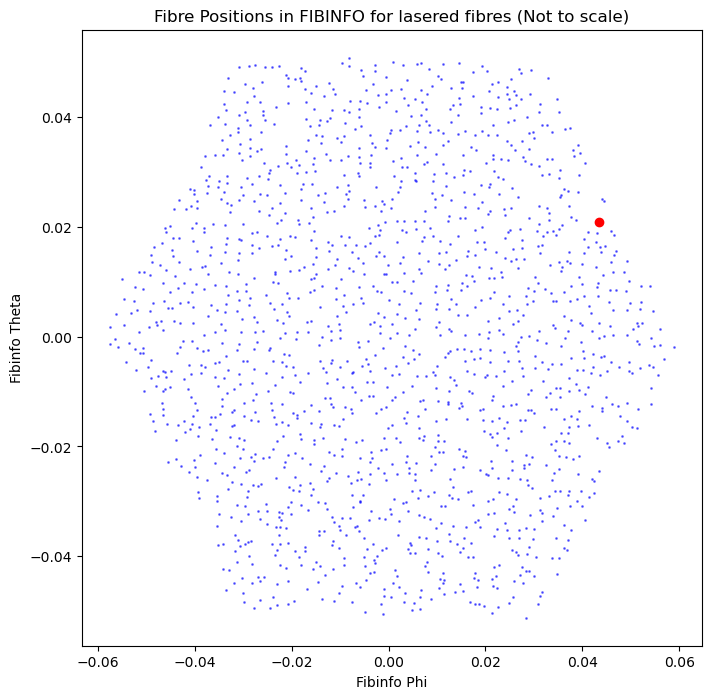

In [28]:
plt.figure(figsize=(8, 8))

for files in range(len(lrs_paths)):
    with fits.open(lrs_paths[files]) as hdulist:
        primary_header = hdulist[0].header
        counts = hdulist['GREEN_DATA']
        ivar = hdulist['GREEN_IVAR']
        noss_flux = hdulist['GREEN_DATA_NOSS'] 
        noss_ivar = hdulist['GREEN_IVAR_NOSS'] 
        sensfunc = hdulist['GREEN_SENSFUNC']
        fibinfo = hdulist['FIBINFO']
        
        green_arm = ReducedArm(HEADER=primary_header, # This is required
                            ARM_DATA=counts, # This is required
                            ARM_IVAR=ivar, # This is required
                            ARM_DATA_NOSS=noss_flux,  # This is optional
                            ARM_IVAR_NOSS=noss_ivar,  # This is optional
                            ARM_SENSFUNC=sensfunc,  # This is optional
                            fibinfo=fibinfo  # This is optional
                            )
        
        # find fibre numbers with a max of more than 400 counts within 5875-5925 Angstrom

        ADU_LIM = 2000

        mask = (green_arm.wavelength.value >= 5875) & (green_arm.wavelength.value <= 5925)
        max_counts = np.max(green_arm.counts2D[:, mask], axis=1)
        fibre_numbers = np.where(max_counts.value > ADU_LIM)[0]

                
        mask2 = (green_arm.wavelength.value >= 5880) & (green_arm.wavelength.value <= 5882)
        max_counts2 = np.max(green_arm.counts2D[:, mask], axis=1)
        print(f'Fibre numbers with max counts > 400 in 5875-5925 Angstrom for {files}: {fibre_numbers}')

        simucal_mask = (green_arm.fibinfo['FIB_USE'] != 0)

        fib_mask_numbers_no_simucal = (simucal_mask) * (max_counts.value > ADU_LIM) * (max_counts2.value > 20)
        fibre_numbers_no_simucal = np.where(fib_mask_numbers_no_simucal)[0]

        print('Fibres without simucal (FIB_USE=0):', fibre_numbers_no_simucal)

        phis = green_arm.fibinfo['FIB_PHI'][simucal_mask]
        thetas = green_arm.fibinfo['FIB_THET'][simucal_mask]

        plt.scatter(phis, thetas, c='blue', alpha=0.5, label=f'Fibres {specs[files]}', s=1)

        for fib_no in fibre_numbers_no_simucal:
            if fib_no != 724:
                plt.scatter(phis[fib_no], thetas[fib_no], c='red', label=f'Fibre {fib_no}')

               # plt.scatter(phis[724], thetas[724], c='green', label=f'Fibre 396')
            

plt.title('Fibre Positions in FIBINFO for lasered fibres (Not to scale)')
plt.xlabel('Fibinfo Phi')
plt.ylabel('Fibinfo Theta')
#plt.legend()
plt.savefig('Check_focal_plane_fib391.png')
plt.show()


Fibre numbers with max counts > 400 in 5875-5925 Angstrom for /Users/sp624AA/Downloads/spv_misc/nt_100051.fit: [  1   2   3   4   5 264 391 528 559 818 819 820 821 822 823]
Fibres without simucal (FIB_USE=0): [264 391 528 559]
Fibre numbers with max counts > 400 in 5875-5925 Angstrom for /Users/sp624AA/Downloads/spv_misc/nt_100050.fit: [  0   1   2   3   4   5  40 179 455 456 457 631 723 724 725 818 819 820
 821 823]
Fibres without simucal (FIB_USE=0): [ 40 179 455 456 457 631]


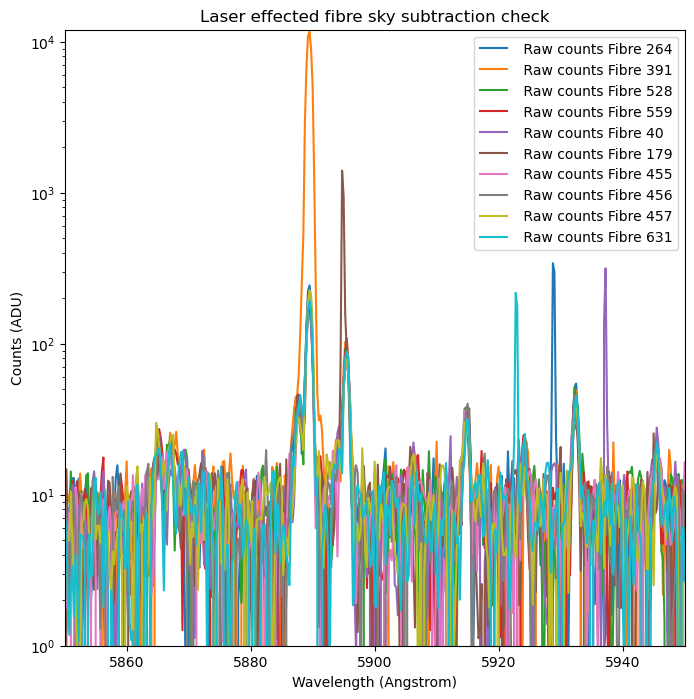

In [27]:
plt.figure(figsize=(8, 8))

for files in lrs_paths:
    with fits.open(files) as hdulist:
        primary_header = hdulist[0].header
        counts = hdulist['GREEN_DATA']
        ivar = hdulist['GREEN_IVAR']
        noss_flux = hdulist['GREEN_DATA_NOSS'] 
        noss_ivar = hdulist['GREEN_IVAR_NOSS'] 
        sensfunc = hdulist['GREEN_SENSFUNC']
        fibinfo = hdulist['FIBINFO']
        
        green_arm = ReducedArm(HEADER=primary_header, # This is required
                            ARM_DATA=counts, # This is required
                            ARM_IVAR=ivar, # This is required
                            ARM_DATA_NOSS=noss_flux,  # This is optional
                            ARM_IVAR_NOSS=noss_ivar,  # This is optional
                            ARM_SENSFUNC=sensfunc,  # This is optional
                            fibinfo=fibinfo  # This is optional
                            )
        
        # find fibre numbers with a max of more than 400 counts within 5875-5925 Angstrom
        ADU_LIM = 200

        mask = (green_arm.wavelength.value >= 5889) & (green_arm.wavelength.value <= 5989.5)
        mask2 = (green_arm.wavelength.value >= 5880) & (green_arm.wavelength.value <= 5882)
        max_counts = np.max(green_arm.counts2D[:, mask], axis=1)
        max_counts2 = np.max(green_arm.counts2D[:, mask2], axis=1)
        fibre_numbers = np.where(max_counts.value > ADU_LIM)[0]
        print(f'Fibre numbers with max counts > 400 in 5875-5925 Angstrom for {files}: {fibre_numbers}')

        simucal_mask = (green_arm.fibinfo['FIB_USE'] != 0)

        fib_mask_numbers_no_simucal = (simucal_mask) * (max_counts.value > ADU_LIM) * (max_counts2.value < 10)
        fibre_numbers_no_simucal = np.where(fib_mask_numbers_no_simucal)[0]

        print('Fibres without simucal (FIB_USE=0):', fibre_numbers_no_simucal)

        phis = green_arm.fibinfo['FIB_PHI'][simucal_mask]
        thetas = green_arm.fibinfo['FIB_THET'][simucal_mask]

        #plt.plot(phis, thetas, c='blue', alpha=0.5, label='Fibres')

        for fib_no in fibre_numbers_no_simucal:
            if fib_no != 724:
                plt.plot(green_arm.wavelength, green_arm.raw_counts2D[fib_no], label=f' Raw counts Fibre {fib_no}')
                #plt.plot(green_arm.wavelength, green_arm.raw_counts2D[fib_no] - green_arm.counts2D[fib_no], label=f'Sky subtraction Fibre {fib_no}')
                #plt.plot(green_arm.wavelength, green_arm.counts2D[fib_no], label=f'Processed counts Fibre {fib_no}')

plt.title('Laser effected fibre sky subtraction check')
plt.legend()
plt.xlim(5850, 5950)
plt.ylim(1, 12000)
plt.yscale('log')
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Counts (ADU)')
plt.savefig('check_skysub_fib391.png')
plt.show()


In [228]:
ra_4most =359.782929
dec_4most = -30.62796

ra_ut4 = 359.7829167
dec_ut4 = -30.6279722

In [231]:
offset_ra = abs(ra_4most - ra_ut4) * 60**2
offset_dec = abs(dec_4most - dec_ut4) * 60**2
print(f'RA offset: {offset_ra} degrees, Dec offset: {offset_dec} degrees')

RA offset: 0.04428000013376732 degrees, Dec offset: 0.04391999998887286 degrees
